<a href="https://colab.research.google.com/github/Berserker268/AI-vs-Human-text-Plagiarism-checker/blob/main/AI_text_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Exploratory Data Analysis (EDA)

AI vs Human Text Detector:


*   **Text:** Consists of essay of both human generated and machine generated
*  **Generated(Target column):** Final verdict on whether it is HGL or MGL

         
         0 = Human
         1 = AI generated


In [4]:

path = "/content/drive/MyDrive/Datasets/AI_Human.csv"
df = pd.read_csv(path)
df.head()


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [5]:
df.shape

(487235, 2)

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB
None


In [7]:
df.describe()

,generated
count,487235.000000
mean,0.372383
std,0.483440
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [8]:
df.nunique()

,0
text,487235
generated,2


Text(0.5, 1.0, 'Total text Distribution: AI vs Human')

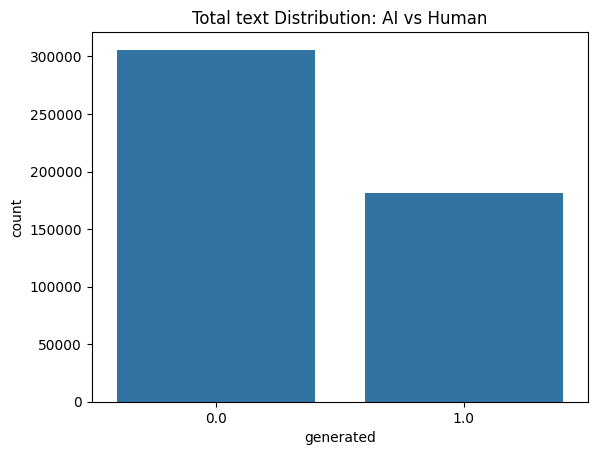

In [9]:
sns.countplot(data=df,x='generated')
plt.title('Total text Distribution: AI vs Human')

In [10]:
print('Total Texts:', df['generated'].count())
print('Human Written Texts:', (df['generated']==0.0).sum())
print('AI Generated Texts:', (df['generated']==1.0).sum())
print(f"Percentage of Human text: {((df['generated']==0.0).sum()/df['generated'].count())*100:.2f} %")
print(f"Percentage of Human text: {((df['generated']==1.0).sum()/df['generated'].count())*100:.2f} %")

Total Texts: 487235
Human Written Texts: 305797
AI Generated Texts: 181438
Percentage of Human text: 62.76 %
Percentage of Human text: 37.24 %


In [11]:
#target_col = 'generated'

#df_sample, _ = train_test_split(df, train_size=0.9, stratify=df[target_col], random_state=42)
#print(f"Sample size: {len(df_sample)}")
#print(df_sample[target_col].value_counts())

#**Text Length Analysis**



In [12]:
df['word_count'] = df['text'].str.count(' ') + 1
df['sentence_count'] = df['text'].str.count(r'[.!?]+').fillna(1)
df['avg_word_len'] = df['text'].str.len() / df['word_count']
df['avg_sent_len'] = df['word_count'] / df['sentence_count']

# KDE plot for word count
Here we used a **KDE** plot to see the probability density of the word count of both human and AI essays.

As we can see that the orange peak is significantly higher and narrower thant the blue peak. Moreover it also proves a hypothesis of one the the research paper we have read that the human generated text contains more burstiness and has the tendency to write more.

Since the  difference is not that much it wont be a good feature but a good data to see.



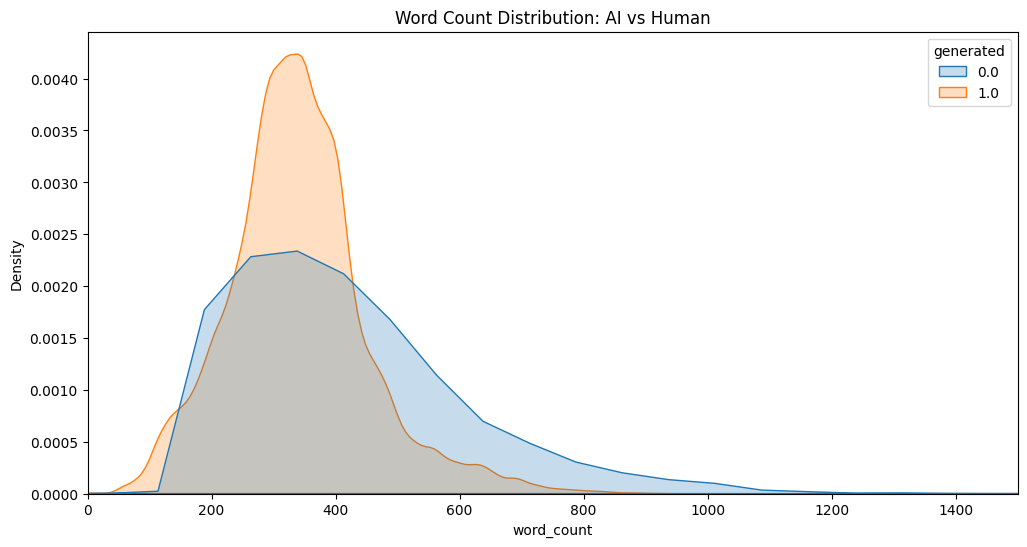

In [13]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x='word_count', hue='generated', fill=True, palette='tab10', common_norm=False)
plt.xlim(0, 1500)

plt.title('Word Count Distribution: AI vs Human')
plt.ylabel('Density')

plt.show()

# KDE plot for sentence length
As we can see the AI is very consistent with its number of words per sentence whereas the human text has a much higher density of short and long sentences.

This might be a good feature to work with.

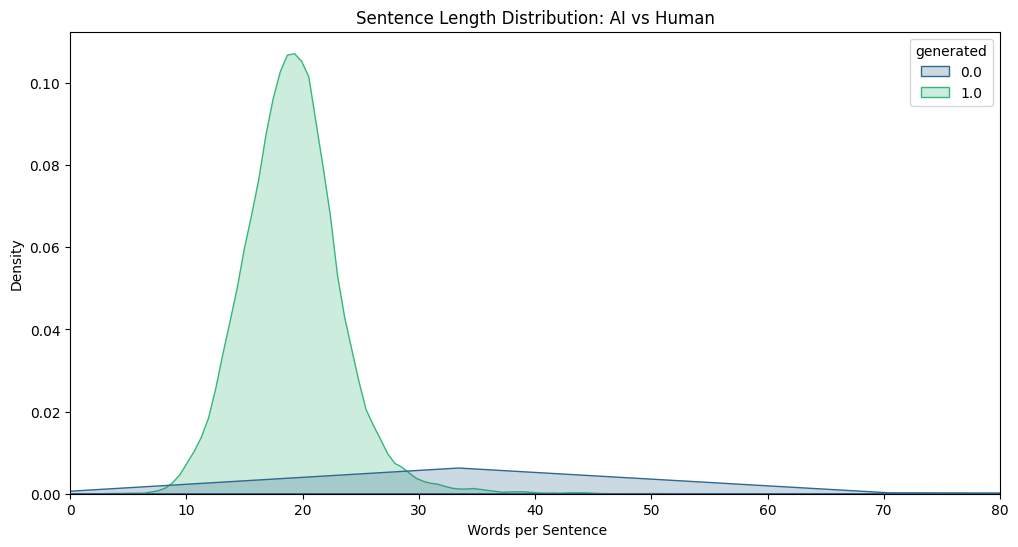

In [14]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='avg_sent_len', hue='generated',
            fill=True, palette='viridis', common_norm=False)
plt.xlim(0, 80)
plt.title('Sentence Length Distribution: AI vs Human')
plt.xlabel(' Words per Sentence')
plt.ylabel('Density')
plt.show()

In [15]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
import string

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [16]:
!pip install textstat

In [17]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Feature Engineering
We extract structural and stylistic features from the text using spaCy and our main focus was stylometric. Instead of vectorizing the text, we calculate numerical metrics that capture the writing paterns created by both AI and human texts. The features extracted are:

- **Punctuation Density**: Ratio of punctuation used to total words
- **Stopword Ratio**: Ratio of stopwords to total words as we can see AI tends to use a predictable distribution of functional words
- **Noun/Verb/Adjective Density**: Ratio of each POS tag to total words to see the different density of each pos tags
- **Sentence Length**: Average number of words per sentence
- **Type-Token Ratio (TTR)**: Unique words used per total words as AI tends to have lower lexical diversity
- **FK Grade**: This is the Readability score.
- ** Fog Index**: Another readability metric used to penalizing complex words as ai tends to use complex words
- **Burstiness**: Standard deviation of sentence lengths as we have previously seen humans have varying sentence lengths
- **Entropy**: Measures the unpredictability of word choices.
- **Avg Word Length**: Average number of characters per word

In [18]:
import spacy
from tqdm import tqdm
import numpy as np
import textstat
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.add_pipe("sentencizer")

texts = df['text'].tolist()
texts = texts[:1000]
df_sample = df.iloc[:1000]
records = []

for doc in tqdm(nlp.pipe(texts, batch_size=500, n_process=1), total=len(texts)):
    word_count = max(1, len(doc))
    sentences = list(doc.sents)
    sent_lengths = [len(sent) for sent in sentences]

    punc_density = sum(t.is_punct for t in doc) / word_count
    stopword = sum(t.is_stop for t in doc) / word_count
    noun_density = sum(t.pos_ == 'NOUN' for t in doc) / word_count
    verb_density = sum(t.pos_ == 'VERB' for t in doc) / word_count
    adj_density = sum(t.pos_ == 'ADJ' for t in doc) / word_count
    sent_length = word_count / max(1, len(sentences))

    words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]

    ttr = len(set(words)) / max(1, len(words))

    fk_grade = textstat.flesch_kincaid_grade(doc.text)
    fog_index = textstat.gunning_fog(doc.text)

    burstiness = np.std(sent_lengths) if len(sent_lengths) > 1 else 0

    word_freq = Counter(words)
    total = sum(word_freq.values())
    probs = [c / total for c in word_freq.values()]
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)

    records.append({
        'punctuation density': punc_density,
        'stopword': stopword,
        'noun density': noun_density,
        'verb density': verb_density,
        'adj density': adj_density,
        'sentence length': sent_length,
        'ttr': ttr,
        'fk_grade': fk_grade,
        'fog_index': fog_index,
        'burstiness': burstiness,
        'entropy': entropy
    })

feature_df = pd.DataFrame(records, index=df_sample.index)
new_df = df_sample.copy()
new_df[feature_df.columns] = feature_df

print(new_df.head())

100%|██████████| 1000/1000 [01:17<00:00, 12.96it/s]


                                                text  generated  word_count  \
0  Cars. Cars have been around since they became ...        0.0         581   
1  Transportation is a large necessity in most co...        0.0         458   
2  "America's love affair with it's vehicles seem...        0.0         740   
3  How often do you ride in a car? Do you drive a...        0.0         684   
4  Cars are a wonderful thing. They are perhaps o...        0.0         868   

   sentence_count  avg_word_len  avg_sent_len  punctuation density  stopword  \
0              24      5.660929     24.208333             0.104545  0.443939   
1              27      5.978166     16.962963             0.115094  0.450943   
2              48      5.983784     15.416667             0.109929  0.468085   
3              51      5.866959     13.411765             0.133663  0.466584   
4              51      5.412442     17.019608             0.105641  0.484103   

   noun density  verb density  adj density  

In [19]:
feature_cols = ['punctuation density', 'stopword', 'noun density', 'verb density',
                'adj density', 'sentence length', 'ttr', 'fk_grade',
                'fog_index', 'burstiness', 'entropy']

new_df.groupby('generated')[feature_cols].mean()

,punctuation density,stopword,noun density,verb density,adj density,sentence length,ttr,fk_grade,fog_index,burstiness,entropy
generated,,,,,,,,,,,
0.0,0.095507,0.493583,0.194185,0.108670,0.065096,23.483298,0.430059,10.195432,12.759321,10.573802,7.099087
1.0,0.076074,0.515457,0.195745,0.110054,0.062265,24.409091,0.434949,11.641856,15.500664,7.664936,6.142471


## Exploratory Data Analysis for feature engineering
Here we compare the distribution of each feature between AI and Human generated text using boxplots. Features where the boxes don't overlap much are the most useful for classification such as burstiness entropy and such.

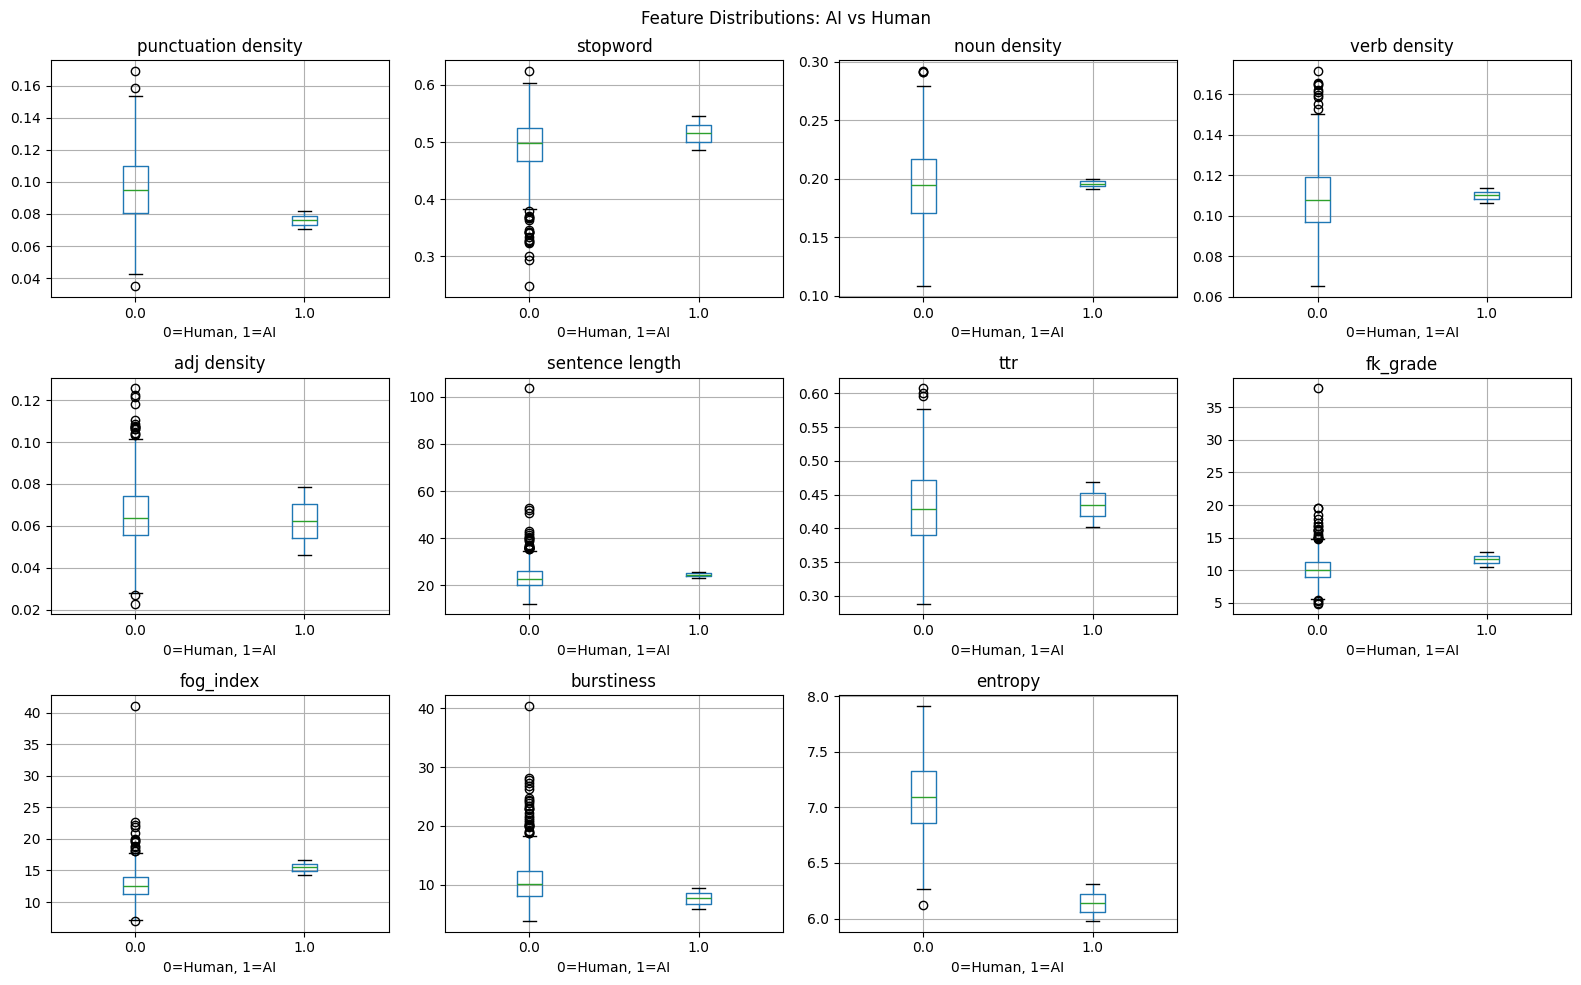

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    new_df.boxplot(column=col, by='generated', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('0=Human, 1=AI')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions: AI vs Human')
plt.tight_layout()
plt.show()

## Data Preparation
We prepare the data for model training by:
1. checking for null values
2. Selecting the 12 features as input and 'generated' as the target y
3. Splitting into 80% training and 20% testing sets
4. Scaling features using StandardScaler so no single feature dominates

In [30]:
print(df.isnull().sum())

text              0
generated         0
word_count        0
sentence_count    0
avg_word_len      0
avg_sent_len      0
dtype: int64


In [23]:
print(new_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text                 1000 non-null   object 
 1   generated            1000 non-null   float64
 2   word_count           1000 non-null   int64  
 3   sentence_count       1000 non-null   int64  
 4   avg_word_len         1000 non-null   float64
 5   avg_sent_len         1000 non-null   float64
 6   punctuation density  1000 non-null   float64
 7   stopword             1000 non-null   float64
 8   noun density         1000 non-null   float64
 9   verb density         1000 non-null   float64
 10  adj density          1000 non-null   float64
 11  sentence length      1000 non-null   float64
 12  ttr                  1000 non-null   float64
 13  fk_grade             1000 non-null   float64
 14  fog_index            1000 non-null   float64
 15  burstiness           1000 non-null   fl

In [25]:
feature_cols = ['punctuation density', 'stopword', 'noun density', 'verb density',
                'adj density', 'sentence length', 'ttr', 'fk_grade',
                'fog_index','burstiness', 'entropy', 'avg_word_len']
X = new_df[feature_cols]
y = new_df['generated']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training size: {len(X_train)}")
print(f"Testing size: {len(X_test)}")

Training size: 800
Testing size: 200


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)